In [1]:
import os
import cv2
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torch.nn.functional as F

# ══════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════
CONFIG = {
    "IMAGE_SIZE": 224,
    "BATCH_SIZE": 32,
    "VAL_PER_CLASS": 200,
    "RANDOM_STATE": 42,
    "EPOCHS": 50,
    "LEARNING_RATE": 0.0001,
    "ES_PATIENCE": 7,
    "LR_PATIENCE": 3,
    "LR_FACTOR": 0.5,
    "MIN_LR": 1e-7,
    "BRIGHTNESS_RANGE": (0.8, 1.2),
    "CONTRAST_RANGE": (0.8, 1.2),
    "DENOISE": True,
    "REQUIRE_GPU": True,
    "LOCAL_TRAIN_DIR": "./Training/",
    "LOCAL_TEST_DIR": "./Testing/",
    "MODEL_SAVE_PATH": "best_model.pth",
}

# ── Device Check ──────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPUs found: {torch.cuda.device_count()} - Using: {torch.cuda.get_device_name(0)}")
else:
    if CONFIG["REQUIRE_GPU"]:
        raise RuntimeError("No GPU detected. Set CONFIG['REQUIRE_GPU'] = False to run on CPU.")
    DEVICE = torch.device("cpu")
    print("  ⚠  No GPU found — running on CPU.")

GPUs found: 1 - Using: NVIDIA GeForce RTX 5060 Ti


In [2]:
# ── Identify Paths and Classes ─────────────────────────────────────────
train_dir = CONFIG["LOCAL_TRAIN_DIR"]
test_dir = CONFIG["LOCAL_TEST_DIR"]

CLASS_LABELS = sorted(os.listdir(train_dir))
n_classes = len(CLASS_LABELS)

train_paths, train_labels = [], []
for label in CLASS_LABELS:
    for img in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, img))
        train_labels.append(CLASS_LABELS.index(label))

val_size = CONFIG["VAL_PER_CLASS"] * n_classes
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=val_size, stratify=train_labels, random_state=CONFIG["RANDOM_STATE"]
)

test_paths, test_labels = [], []
for label in CLASS_LABELS:
    for img in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, img))
        test_labels.append(CLASS_LABELS.index(label))
test_paths, test_labels = shuffle(test_paths, test_labels)

# ── PyTorch Dataset Class ──────────────────────────────────────────────
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = labels
        self.augment = augment
        self.size = CONFIG["IMAGE_SIZE"]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        # Denoising
        if CONFIG["DENOISE"]:
            arr = np.array(image)
            arr = cv2.GaussianBlur(arr, (3, 3), 0)
            image = Image.fromarray(arr)

        # Augmentation
        if self.augment:
            lo_b, hi_b = CONFIG["BRIGHTNESS_RANGE"]
            lo_c, hi_c = CONFIG["CONTRAST_RANGE"]
            image = ImageEnhance.Brightness(image).enhance(random.uniform(lo_b, hi_b))
            image = ImageEnhance.Contrast(image).enhance(random.uniform(lo_c, hi_c))

        # Base Transforms (Resize and to Tensor scaled 0-1)
        transform = transforms.Compose([
            transforms.Resize((self.size, self.size)),
            transforms.ToTensor() 
        ])
        
        img_tensor = transform(image)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return img_tensor, label_tensor

# DataLoaders
train_loader = DataLoader(BrainTumorDataset(train_paths, train_labels, augment=True), batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader = DataLoader(BrainTumorDataset(val_paths, val_labels, augment=False), batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader = DataLoader(BrainTumorDataset(test_paths, test_labels, augment=False), batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

In [3]:
# Load pre-trained VGG16
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 3 convolutional layers (block5_conv1, conv2, conv3)
# In PyTorch VGG16, the last conv layers are at indices 24, 26, 28 in model.features
for i in [24, 26, 28]:
    for param in model.features[i].parameters():
        param.requires_grad = True

# Replace the classifier matching Keras structure
# 512 channels * 7 * 7 spatial dimensions from VGG features = 25088
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(25088, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, n_classes) # No Softmax here, handled by CrossEntropyLoss
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["LEARNING_RATE"])

# Equivalent to ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=CONFIG["LR_FACTOR"], 
    patience=CONFIG["LR_PATIENCE"], min_lr=CONFIG["MIN_LR"]
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:54<00:00, 4.84MB/s] 


In [4]:
# Tell all layers (like ReLU) to stop using in-place memory modifications
for module in model.modules():
    if hasattr(module, 'inplace'):
        module.inplace = False

In [5]:
best_val_loss = float('inf')
patience_counter = 0
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print(f"[Training] Starting on {DEVICE}...")

for epoch in range(CONFIG["EPOCHS"]):
    # -- Training Phase --
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(train_paths)
    train_acc = correct / total
    
    # -- Validation Phase --
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_loss = val_running_loss / len(val_paths)
    val_acc = val_correct / val_total
    
    # Store history
    history['loss'].append(train_loss); history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{CONFIG['EPOCHS']} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # LR Scheduler Step
    scheduler.step(val_loss)
    
    # -- Early Stopping & Model Checkpoint --
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CONFIG["MODEL_SAVE_PATH"])
        print(f"   [*] Val loss improved. Model saved to {CONFIG['MODEL_SAVE_PATH']}")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG["ES_PATIENCE"]:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load the best weights back into the model before testing
model.load_state_dict(torch.load(CONFIG["MODEL_SAVE_PATH"]))

[Training] Starting on cuda...
Epoch 1/50 - Loss: 0.3508, Acc: 0.8679 - Val Loss: 0.1475, Val Acc: 0.9463
   [*] Val loss improved. Model saved to best_model.pth
Epoch 2/50 - Loss: 0.1117, Acc: 0.9579 - Val Loss: 0.1320, Val Acc: 0.9575
   [*] Val loss improved. Model saved to best_model.pth
Epoch 3/50 - Loss: 0.0507, Acc: 0.9819 - Val Loss: 0.0945, Val Acc: 0.9700
   [*] Val loss improved. Model saved to best_model.pth
Epoch 4/50 - Loss: 0.0167, Acc: 0.9952 - Val Loss: 0.1050, Val Acc: 0.9762
Epoch 5/50 - Loss: 0.0330, Acc: 0.9888 - Val Loss: 0.1004, Val Acc: 0.9637
Epoch 6/50 - Loss: 0.0136, Acc: 0.9954 - Val Loss: 0.1452, Val Acc: 0.9675
Epoch 7/50 - Loss: 0.0087, Acc: 0.9971 - Val Loss: 0.1300, Val Acc: 0.9650
Epoch 8/50 - Loss: 0.0032, Acc: 0.9994 - Val Loss: 0.1167, Val Acc: 0.9712
Epoch 9/50 - Loss: 0.0010, Acc: 1.0000 - Val Loss: 0.1217, Val Acc: 0.9725
Epoch 10/50 - Loss: 0.0007, Acc: 1.0000 - Val Loss: 0.1608, Val Acc: 0.9637
Early stopping triggered at epoch 10


<All keys matched successfully>

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.83      0.89       400
  meningioma       0.89      0.94      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600



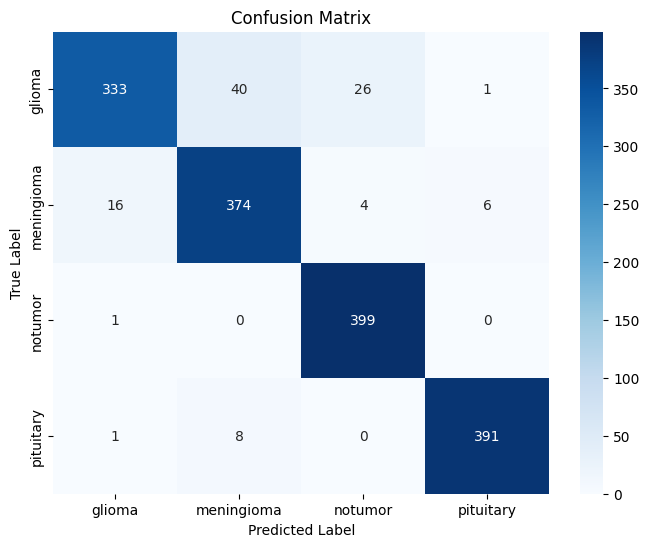

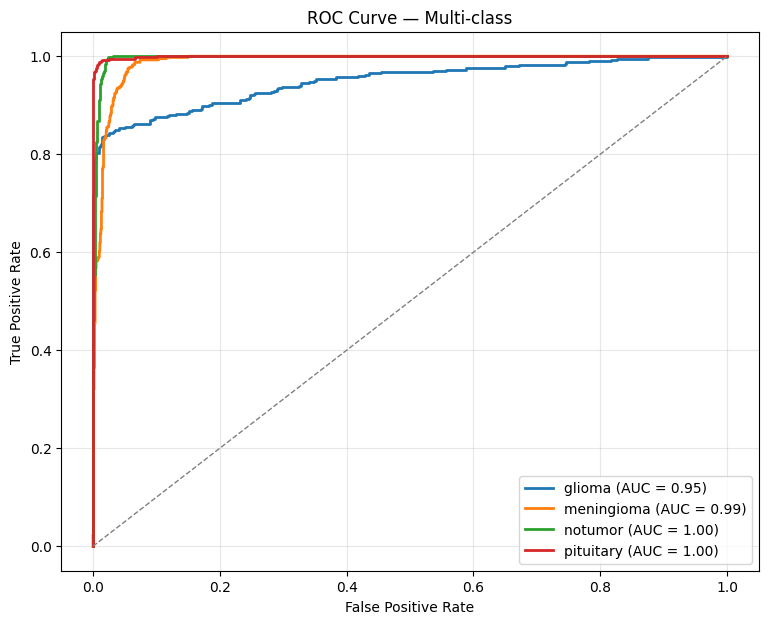

In [6]:
# ── Collect Test Predictions ────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1) # Convert logits to probabilities
        
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ── Classification Report ───────────────────────────────────────────────
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_LABELS))

# ── Confusion Matrix ────────────────────────────────────────────────────
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ── ROC Curve ───────────────────────────────────────────────────────────
test_labels_bin = label_binarize(all_labels, classes=np.arange(n_classes))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 7))
for i, cls in enumerate(CLASS_LABELS):
    plt.plot(fpr[i], tpr[i], label=f"{cls} (AUC = {roc_auc[i]:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
plt.title("ROC Curve — Multi-class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [7]:
# ── PyTorch Grad-CAM Hook System ────────────────────────────────────────
class PyTorchGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        # Clone and detach instantly to avoid inplace downstream modifications
        self.activations = output.clone().detach()

    def save_gradient(self, module, grad_input, grad_output):
        # Clone and detach the gradient instantly
        self.gradients = grad_output[0].clone().detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        # Target for backprop
        target = output[0, class_idx]
        target.backward()
        
        # Pool gradients across spatial dimensions
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # 1. Clone the activations to disconnect them from the hook's view
        activations = self.activations[0].clone()
        
        # 2. Weight activations by gradients using broadcasting (no in-place loops!)
        activations = activations * pooled_gradients.view(-1, 1, 1)
            
        # Create heatmap
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8) # Normalize
        
        return heatmap, class_idx, F.softmax(output, dim=1).detach().cpu().numpy()[0]


# ── Inference and Display Function ─────────────────────────────────────
def detect_and_display(img_path, model):
    print(f"[Inference] Device: {DEVICE}  |  Image: {img_path}")
    
    # 1. Load Original
    orig_img = np.array(Image.open(img_path).convert('RGB'))
    
    # 2. Preprocess
    dataset_dummy = BrainTumorDataset([img_path], [0], augment=False)
    img_tensor, _ = dataset_dummy[0]
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE) # Add batch dimension
    
    # 3. Setup Grad-CAM attached to the final VGG16 Conv layer
    model.eval()
    grad_cam = PyTorchGradCAM(model, model.features[28]) # target: block5_conv3
    
    # 4. Generate Heatmap
    heatmap, pred_idx, probs = grad_cam.generate(img_tensor)
    confidence = probs[pred_idx]
    label = CLASS_LABELS[pred_idx]
    
    # 5. Overlay Creation
    h, w = orig_img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(orig_img, 0.6, heatmap_colored, 0.4, 0)
    
    # 6. Plotting
    result = 'No Tumor' if label == 'notumor' else f'Tumor: {label.capitalize()}'
    title_color = 'green' if label == 'notumor' else 'red'
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(orig_img)
    axes[0].set_title('Original MRI')
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f'{result}\nConfidence: {confidence*100:.2f}%', color=title_color, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

    # Probability Breakdown
    print(f"\nResult     : {result}")
    print(f"Confidence : {confidence*100:.2f}%\n")
    print("All class probabilities:")
    for lbl, prob in sorted(zip(CLASS_LABELS, probs), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"  {lbl:12s}: {prob*100:5.1f}%  {bar}")



[Inference] Device: cuda  |  Image: ./Testing/meningioma/Te-aug-me_6.jpg


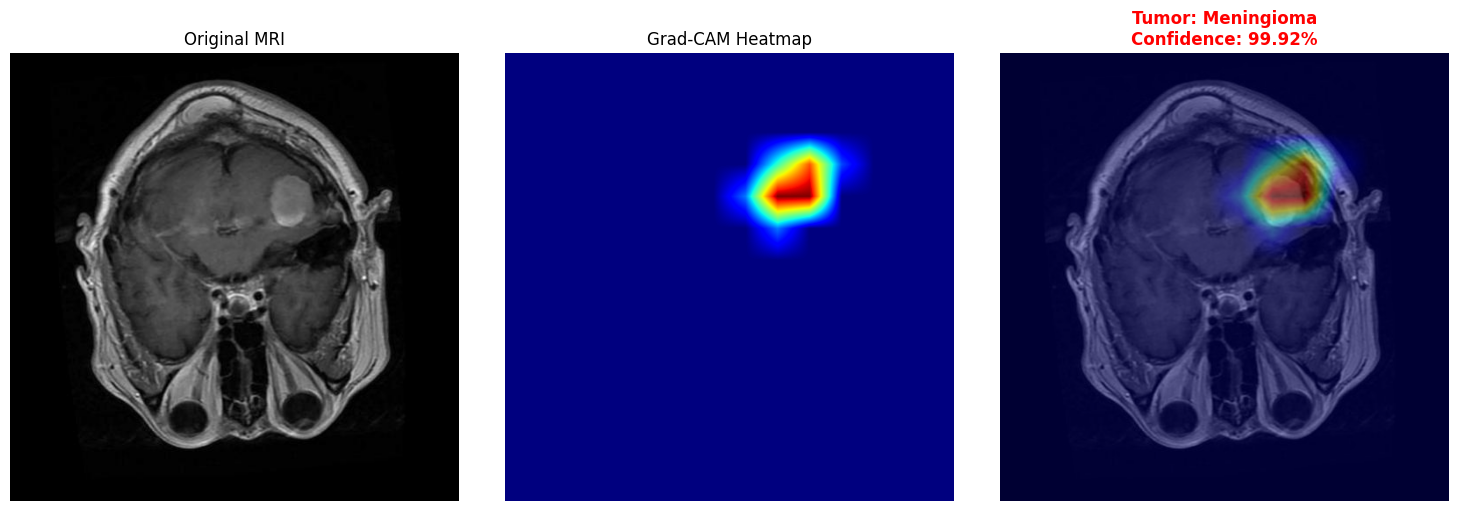


Result     : Tumor: Meningioma
Confidence : 99.92%

All class probabilities:
  meningioma  :  99.9%  █████████████████████████████
  glioma      :   0.1%  
  notumor     :   0.0%  
  pituitary   :   0.0%  


In [8]:
# Example usage
image_path = './Testing/meningioma/Te-aug-me_6.jpg'
detect_and_display(image_path, model)

[Inference] Device: cuda  |  Image: ./Testing/notumor/Te-no_63.jpg


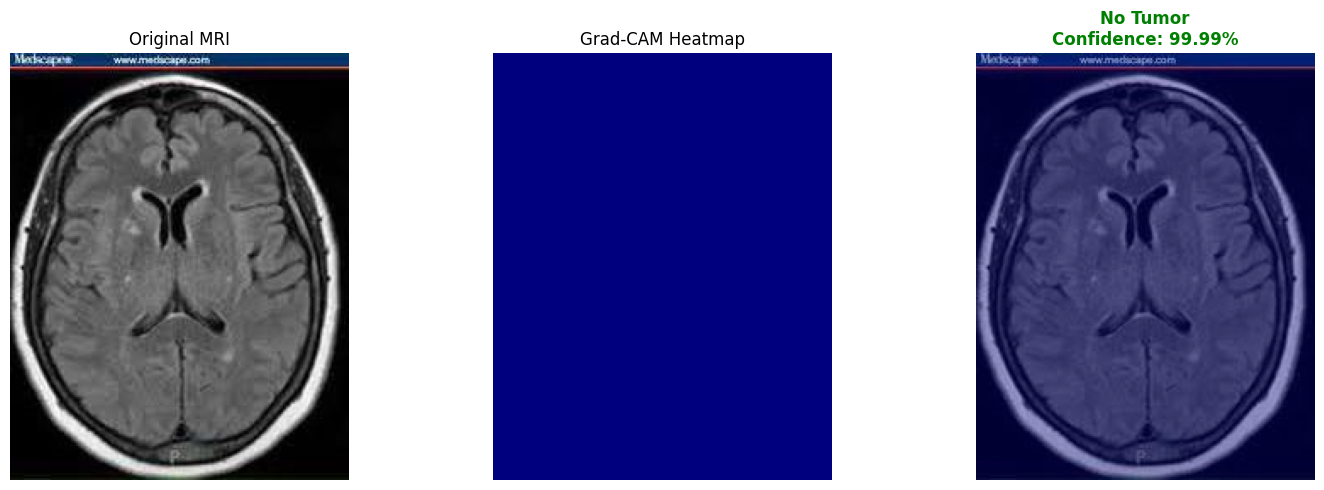


Result     : No Tumor
Confidence : 99.99%

All class probabilities:
  notumor     : 100.0%  █████████████████████████████
  meningioma  :   0.0%  
  glioma      :   0.0%  
  pituitary   :   0.0%  


In [9]:
# Example usage
image_path = './Testing/notumor/Te-no_63.jpg'
detect_and_display(image_path, model)

[Inference] Device: cuda  |  Image: ./Testing/pituitary/Te-pi_64.jpg


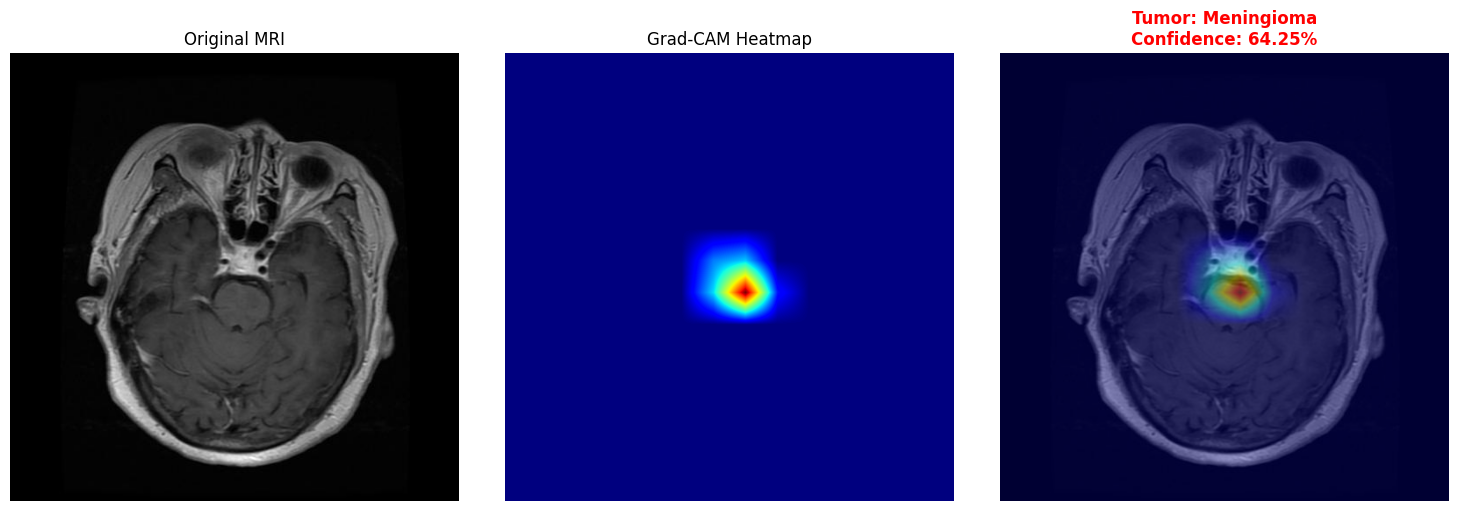


Result     : Tumor: Meningioma
Confidence : 64.25%

All class probabilities:
  meningioma  :  64.3%  ███████████████████
  glioma      :  22.5%  ██████
  pituitary   :  12.9%  ███
  notumor     :   0.3%  


In [10]:
# Example usage
image_path = './Testing/pituitary/Te-pi_64.jpg'
detect_and_display(image_path, model)

[Inference] Device: cuda  |  Image: ./Testing/glioma/Te-gl_8.jpg


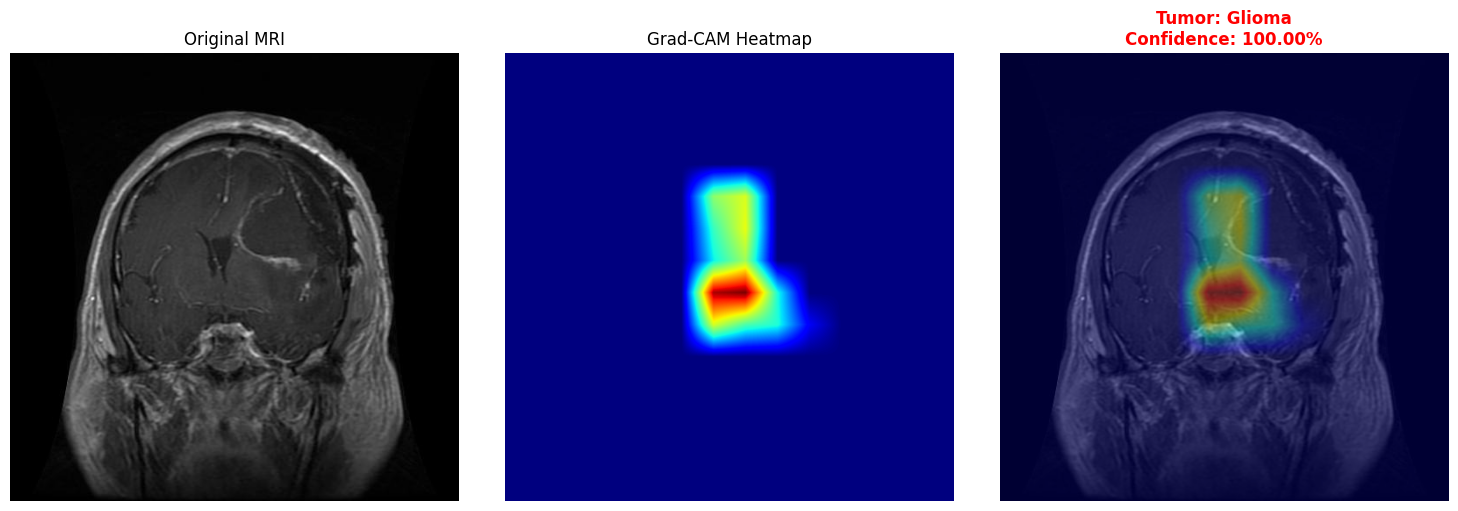


Result     : Tumor: Glioma
Confidence : 100.00%

All class probabilities:
  glioma      : 100.0%  ██████████████████████████████
  meningioma  :   0.0%  
  notumor     :   0.0%  
  pituitary   :   0.0%  


In [11]:
# Example usage
image_path = './Testing/glioma/Te-gl_8.jpg'
detect_and_display(image_path, model)